In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [1]:
from google.colab import files
uploaded=files.upload()

Saving train.csv.xlsx to train.csv.xlsx


In [3]:
df = pd.read_excel("train.csv.xlsx")

In [4]:
df.head()
# print(pr)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


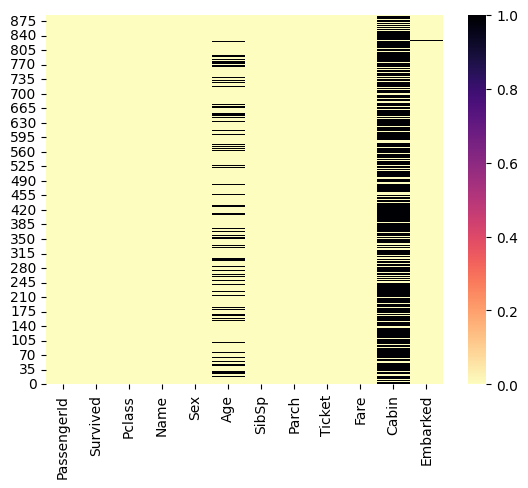

In [7]:
sb.heatmap(df.isnull(), cmap = 'magma_r')
# sb.heatmap(df.isnull(), cmap=sb.color_palette("magma", as_cmap=True).reversed())
plt.gca().invert_yaxis() # flips the y-axis plt.show()

In [8]:
cabin_list = [ 'A', 'B', 'C', 'D', 'E', 'F', 'T', 'G', 'Unknown' ]

In [9]:
def search_substring(big_string, substring_list):
    for substring in substring_list:
        if substring in big_string:
            return substring
    return substring_list[-1]   # return last element if none found

In [10]:
def get_title(string): # function get_title and it has a parameter string, that string contains passenger name
    import re #regular expression module is used for pattern matching or also known as regex library
    reg = re.compile(r'Mr|Don|Major|Capt|Jonkheer|Rev|Col|Dr|Mrs|Countess|Dona|Mme|Ms|Miss|Mile|Master', re.IGNORECASE) #it ignore upper or lower,
    # it provide it original form
    results = reg.search(string)
    if results != None:
        return (results.group().lower()) #lower() it will take it as smaller
    else:
        return(str(np.nan))

In [11]:
get_title("Braund, Mr. Owen Harris") # regex will take all value and match it with any titles

'mr'

In [12]:
# dictionary to map to generate the new feature vector
title_dictionary = {
"capt":"Officer",
"col":"Officer",
"major":"Officer",
"dr":"Officer",
"jonkheer":"Royalty",
"rev":"Officer",
"countess":"Royalty",
"dona":"Royalty",
"lady":"Royalty",
"don":"Royalty",
"mr":"Mr",
"mme":"Mrs",
"ms":"Mrs",
"mrs":"Mrs",
"miss":"Miss",
"mlle":"Miss",
"master":"Master",
"nan":"Mr"
}

In [13]:
df['Deck'] = df['Cabin'].map(lambda x: search_substring(str(x), cabin_list))

In [14]:
df.drop('Cabin', axis = 1, inplace = True)

In [15]:
df['Title'] = df['Name'].apply(get_title)

In [16]:
df['Title'] = df['Title'].map(title_dictionary)

In [17]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Title
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,S,Unknown,Officer
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,S,B,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,S,Unknown,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C,C,Mr
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q,Unknown,Mr


In [18]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mr
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,Mr
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown,Mr


In [19]:
df.drop('Name',axis=1,inplace=True)

In [20]:
df.tail()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Title
886,887,0,2,male,27.0,0,0,211536,13.00,S,Unknown,Officer
887,888,1,1,female,19.0,0,0,112053,30.00,S,B,Miss
888,889,0,3,female,NaN,1,2,W./C. 6607,23.45,S,Unknown,Miss
889,890,1,1,male,26.0,0,0,111369,30.00,C,C,Mr
890,891,0,3,male,32.0,0,0,370376,7.75,Q,Unknown,Mr


In [21]:
df.drop("Ticket",axis=1,inplace=True)

In [22]:
df.tail()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,Title
886,887,0,2,male,27.0,0,0,13.00,S,Unknown,Officer
887,888,1,1,female,19.0,0,0,30.00,S,B,Miss
888,889,0,3,female,NaN,1,2,23.45,S,Unknown,Miss
889,890,1,1,male,26.0,0,0,30.00,C,C,Mr
890,891,0,3,male,32.0,0,0,7.75,Q,Unknown,Mr


In [23]:
means_title=df.groupby('Title')['Age'].mean()


Text(0.5, 1.0, 'Average Age by Title')

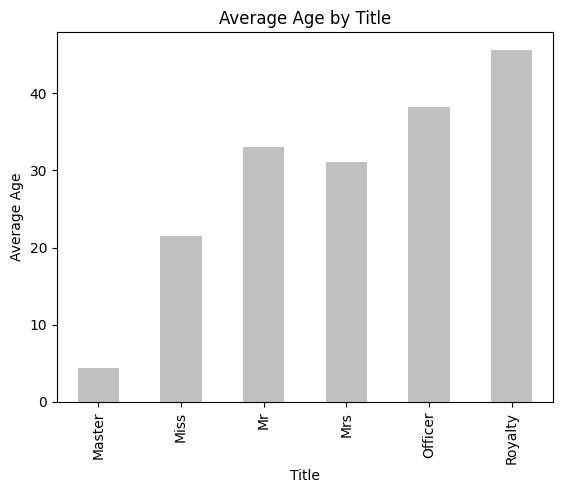

In [24]:
mk=df.groupby('Title')['Age'].mean().plot(kind='bar',color='silver')
plt.xlabel('Title')
plt.ylabel('Average Age')
plt.title('Average Age by Title')

In [25]:
title_list = ['Mr', 'Miss', 'Mrs', 'Master', 'Royalty', 'Officer']
def age_nan_replace(means, dframe, title_list):
    for title in title_list:
        temp = dframe['Title'] == title
        dframe.loc[temp, 'Age'] = dframe.loc[temp, 'Age'].fillna(means[title])
age_nan_replace(means_title, df, title_list)
# age_nan_replace(means_title, title_list)

<Axes: >

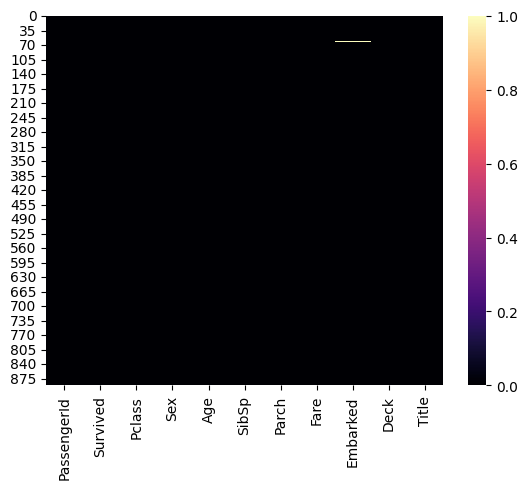

In [26]:
sb.heatmap(df.isnull(),cmap="magma")

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
 9   Deck         891 non-null    object 
 10  Title        891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [28]:
df['Embarked'].fillna('S',inplace=True)

/tmp/ipykernel_2611/3895404187.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna('S',inplace=True)


In [29]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,Title
0,1,0,3,male,22.0,1,0,7.2500,S,Unknown,Mr
1,2,1,1,female,38.0,1,0,71.2833,C,C,Mr
2,3,1,3,female,26.0,0,0,7.9250,S,Unknown,Miss
3,4,1,1,female,35.0,1,0,53.1000,S,C,Mr
4,5,0,3,male,35.0,0,0,8.0500,S,Unknown,Mr


In [30]:
df['Family Size']=df['Parch']+df['SibSp']

In [31]:
df.drop('Parch',axis=1,inplace=True)

In [32]:
df.drop('SibSp',axis=1,inplace=True)

In [33]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Deck,Title,Family Size
0,1,0,3,male,22.0,7.2500,S,Unknown,Mr,1
1,2,1,1,female,38.0,71.2833,C,C,Mr,1
2,3,1,3,female,26.0,7.9250,S,Unknown,Miss,0
3,4,1,1,female,35.0,53.1000,S,C,Mr,1
4,5,0,3,male,35.0,8.0500,S,Unknown,Mr,0


In [34]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})  #label Encoding

In [35]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Deck,Title,Family Size
0,1,0,3,0,22.0,7.2500,S,Unknown,Mr,1
1,2,1,1,1,38.0,71.2833,C,C,Mr,1
2,3,1,3,1,26.0,7.9250,S,Unknown,Miss,0
3,4,1,1,1,35.0,53.1000,S,C,Mr,1
4,5,0,3,0,35.0,8.0500,S,Unknown,Mr,0


In [36]:
#Machinelearning Model
df = df[['Sex', 'Age', 'Pclass', 'Survived']]

In [37]:
X = df[['Sex', 'Age', 'Pclass']]
y = df['Survived']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [41]:
person = [[1, 25, 1]]

In [42]:
prediction = model.predict(person)
print("Predicted Survival Probability:", prediction[0])

Predicted Survival Probability: 0.973316766613481


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [43]:
#Regression model
from sklearn.linear_model import LogisticRegression

In [44]:
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

In [45]:
person = [[1, 25, 1]]

In [46]:
prediction = model.predict(person)
print("Predicted Survival Probability:", prediction[0])

Predicted Survival Probability: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [47]:
prob = model.predict_proba(person)
print("Probability of Not Surviving:", prob[0][0])
print("Probability of Surviving:", prob[0][1])

Probability of Not Surviving: 0.06605898157775425
Probability of Surviving: 0.9339410184222458


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
